# Per-Series Importance with Exogenous Features

This notebook demonstrates a powerful use case for per-series feature importance: **detecting heterogeneous effects of exogenous features across different time series**.

## The Problem

In multi-series forecasting, exogenous features (like temperature, promotions, or holidays) often have different effects on different series or groups:
- Temperature might strongly affect sales in urban areas but not rural areas
- Holiday flags might boost tourism in rural areas but have little effect on urban commuter markets

**Global feature importance analysis masks these heterogeneous effects**, showing only an "average" importance that may not reflect any individual series or group accurately.

## The Solution

Using `explain_per_series()`, we can compute feature importance separately for each series, revealing which exogenous features truly matter for each specific time series and group.

## Generic Design

This notebook uses parameterized, reusable notation:
- **Groups**: Categorical partition (e.g., `group_a`, `group_b`) - can represent any business segments (urban/rural, product lines, regions, etc.)
- **Exogenous Features**: Generic names (`exog_feature_1`, `exog_feature_2`, `exog_feature_3`) with concrete example documentation
- **Heterogeneous Effects**: Different groups respond differently to features


In [29]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.model_selection import bayesian_search_forecaster_multiseries, TimeSeriesFold

from xeries import (
    ConditionalPermutationImportance,
    SkforecastAdapter,
    plot_importance_bar,
    plot_importance_heatmap,
    plot_importance_per_series,
)

sns.set_theme(style='whitegrid')
print('Imports loaded.')

Imports loaded.


## 1. Generate Synthetic Data with Heterogeneous Exogenous Effects

We create 6 time series across 2 groups with **daily** data. The key insight is that **different exogenous features affect different groups**:

### Data Generation Logic

**Target Variable**:
```
target[t] = base_level + AR_effect + weekly_seasonality + trend + exogenous_effects + noise
```

Where:
- `base_level`: Different baseline for each series (100, 140, 180)
- `AR_effect`: 0.3 × target[t-1] (autoregressive component)
- `weekly_seasonality`: 10 × sin(2π × t / 7) - captures weekly patterns
- `trend`: Linear growth from 0 to 10 over the period
- `noise`: Random normal with σ=3

**Exogenous Feature Effects** (Generic → Concrete Example):

| Feature | Type | group_a | group_b |
|---------|------|---------|---------|
| `exog_feature_1` | Continuous (e.g., temperature) | **+0.8 × (feat - 15)** | 0 (no effect) |
| `exog_feature_2` | Binary (e.g., holiday flag) | 0 (no effect) | **+25 per holiday** |
| `exog_feature_3` | Binary (e.g., promotion) | **+15 per promo day** | **+15 per promo day** |

This design ensures:
- **group_a**: Responds to exog_feature_1 only (e.g., temperature-sensitive urban stores)
- **group_b**: Responds to exog_feature_2 only (e.g., holiday-sensitive rural stores)
- **All groups**: Respond equally to exog_feature_3 (promotions)

Data shape: (10950, 7)
Series: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']

Region mapping:
  urban_001: urban
  urban_002: urban
  urban_003: urban
  rural_001: rural
  rural_002: rural
  rural_003: rural

Exogenous features: temperature, holiday_flag, promotion


,date,series_id,region,value,temperature,holiday_flag,promotion
0,2023-01-01,urban_001,urban,100.000000,22.490142,0.0,1.0
1,2023-01-02,urban_001,urban,93.783033,20.791767,0.0,0.0
2,2023-01-03,urban_001,urban,99.358064,23.356125,0.0,0.0
3,2023-01-04,urban_001,urban,108.171557,26.188526,0.0,1.0
4,2023-01-05,urban_001,urban,94.466204,21.123169,0.0,1.0
5,2023-01-06,urban_001,urban,73.531687,21.329167,1.0,0.0
6,2023-01-07,urban_001,urban,85.715610,26.974859,0.0,1.0
7,2023-01-08,urban_001,urban,84.969123,24.744801,1.0,0.0
8,2023-01-09,urban_001,urban,89.216891,21.238922,0.0,0.0
9,2023-01-10,urban_001,urban,97.020716,24.479386,0.0,0.0


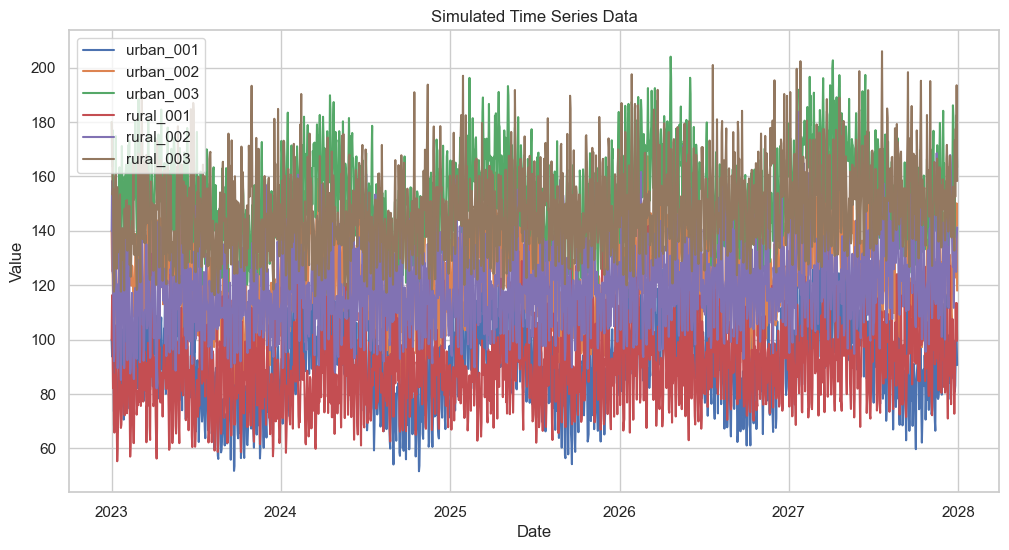

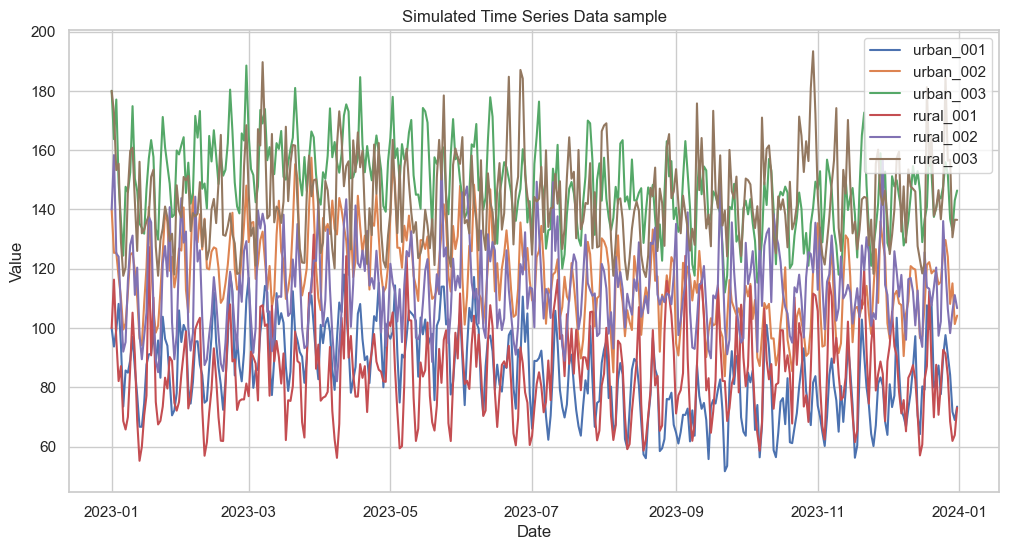

In [ ]:
np.random.seed(42)

# =============================================================================
# CONFIGURATION: Experiment Setup (Parameterized & Reusable)
# =============================================================================

# --- Group Definition (generic, can be any categorical partition) ---
N_GROUPS = 2
GROUPS = ['group_a', 'group_b']
N_SERIES_PER_GROUP = 3
TOTAL_SERIES = N_GROUPS * N_SERIES_PER_GROUP

# --- Exogenous Feature Definition (generic, can represent any features) ---
N_EXOG_FEATURES = 3
EXOG_FEATURE_NAMES = ['exog_feature_1', 'exog_feature_2', 'exog_feature_3']

# Documentation of what each feature represents in the example scenario:
EXOG_FEATURE_DOCS = {
    'exog_feature_1': 'Continuous feature (e.g., temperature): affects group_a only',
    'exog_feature_2': 'Binary feature (e.g., holiday flag): affects group_b only',
    'exog_feature_3': 'Binary feature (e.g., promotion): affects all groups equally',
}

# --- Time Series Parameters ---
N_DAYS = 365 * 5  # ~5 years of daily data per series
RANDOM_SEED = 42

print(f'Configuration loaded:')
print(f'  Groups: {GROUPS} (N={N_GROUPS})')
print(f'  Series per group: {N_SERIES_PER_GROUP} → Total: {TOTAL_SERIES}')
print(f'  Exogenous features: {EXOG_FEATURE_NAMES} (N={N_EXOG_FEATURES})')
print(f'  Time series length: {N_DAYS} days')

# =============================================================================
# GENERATE SYNTHETIC DATA
# =============================================================================

all_data = []
series_ids = []
groups_list = []

series_idx = 0
for group_idx, group in enumerate(GROUPS):
    for series_in_group in range(N_SERIES_PER_GROUP):
        np.random.seed(RANDOM_SEED + series_idx)
        
        dates = pd.date_range(start='2023-01-01', periods=N_DAYS, freq='D')
        
        # =================================================================
        # EXOGENOUS FEATURES
        # =================================================================
        
        # exog_feature_1: continuous (e.g., temperature)
        # group_a has warmer climate (+8°C offset), group_b has cooler climate (-8°C offset)
        climate_offset = 8 if group_idx == 0 else -8
        store_variation = (series_in_group % 3) * 2 - 2  # -2, 0, +2 variation per series
        exog_feature_1 = (15 + climate_offset + store_variation + 
                         12 * np.sin(2 * np.pi * np.arange(N_DAYS) / 365) + 
                         np.random.normal(0, 3, N_DAYS))
        
        # exog_feature_2: binary (e.g., holiday flag) - ~15% of days
        exog_feature_2 = (np.random.random(N_DAYS) > 0.85).astype(float)
        
        # exog_feature_3: binary (e.g., promotion) - ~30% of days
        exog_feature_3 = (np.random.random(N_DAYS) > 0.7).astype(float)
        
        # =================================================================
        # TARGET VARIABLE COMPONENTS
        # =================================================================
        
        base = 100 + (series_in_group % 3) * 40  # Series size variation: 100, 140, 180
        trend = np.linspace(0, 10, N_DAYS)
        weekly_pattern = 10 * np.sin(2 * np.pi * np.arange(N_DAYS) / 7)
        
        values = np.zeros(N_DAYS)
        values[0] = base
        
        # =================================================================
        # GENERATE TARGET WITH HETEROGENEOUS EXOGENOUS EFFECTS
        # =================================================================
        for t in range(1, N_DAYS):
            ar_effect = 0.3 * values[t-1]
            
            # HETEROGENEOUS EFFECTS: Different groups respond differently
            if group_idx == 0:  # group_a: affected by exog_feature_1 only
                feat1_effect = 0.8 * (exog_feature_1[t] - 15)
                feat2_effect = 0.0  # No effect from exog_feature_2
            else:  # group_b: affected by exog_feature_2 only
                feat1_effect = 0.0  # No effect from exog_feature_1
                feat2_effect = 25.0 * exog_feature_2[t]
            
            # exog_feature_3 (promotion) affects all groups equally
            feat3_effect = 15.0 * exog_feature_3[t]
            
            values[t] = (
                base * 0.5 + ar_effect + weekly_pattern[t] + trend[t] +
                feat1_effect + feat2_effect + feat3_effect +
                np.random.normal(0, 3)
            )
        
        # Store this series
        series_id = f'{group}_{series_in_group+1:03d}'
        df = pd.DataFrame({
            'date': dates,
            'series_id': series_id,
            'group': group,
            'value': values,
            EXOG_FEATURE_NAMES[0]: exog_feature_1,
            EXOG_FEATURE_NAMES[1]: exog_feature_2,
            EXOG_FEATURE_NAMES[2]: exog_feature_3,
        })
        all_data.append(df)
        series_ids.append(series_id)
        groups_list.append(group)
        
        series_idx += 1

data = pd.concat(all_data, ignore_index=True)

print(f"\nData shape: {data.shape}")
print(f"Series: {data['series_id'].unique().tolist()}")
print(f"\nGroup mapping:")
for s, g in zip(series_ids, groups_list):
    print(f"  {s}: {g}")
print(f"\nExogenous features: {EXOG_FEATURE_NAMES}")

# Plot all series
plt.figure(figsize=(12, 6))
for series_id in series_ids:
    subset = data[data['series_id'] == series_id]
    plt.plot(subset['date'], subset['value'], label=series_id, alpha=0.7)
plt.title('Simulated Multi-Series Data (All 5 years)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# Plot 1 year sample for better detail
plt.figure(figsize=(12, 6))
for series_id in series_ids:
    subset = data[data['series_id'] == series_id][:365]
    plt.plot(subset['date'], subset['value'], label=series_id, alpha=0.7)
plt.title('Simulated Multi-Series Data (First 1 year sample)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

display(data.head(10))

## 2. Prepare Multi-Series Inputs for skforecast

`skforecast` creates lagged features internally, so we prepare:
- `series_dict`: one target series per `series_id`
- `exog_dict`: aligned exogenous features per `series_id`

In [ ]:
# Prepare skforecast inputs: dictionaries keyed by series_id
series_dict = {}
exog_dict = {}

for series_id in series_ids:
    subset = (
        data[data['series_id'] == series_id]
        .sort_values('date')
        .set_index('date')
        .asfreq('D')
    )
    series_dict[series_id] = subset['value'].rename(series_id)
    exog_dict[series_id] = subset[EXOG_FEATURE_NAMES]

# Series mapping for readable output
series_mapping = {s: i for i, s in enumerate(series_ids)}
reverse_mapping = {v: k for k, v in series_mapping.items()}

print(f"Number of series: {len(series_dict)}")
print(f"Rows per series (example {series_ids[0]}): {len(series_dict[series_ids[0]])}")
print(f"Series index frequency: {series_dict[series_ids[0]].index.freq}")
print(f"Exogenous features: {EXOG_FEATURE_NAMES}")
print(f"\nFeature documentation:")
for feat, doc in EXOG_FEATURE_DOCS.items():
    print(f"  {feat}: {doc}")
display(exog_dict[series_ids[0]].head())

Number of series: 6
Rows per series (example urban_001): 1825
Series index frequency: <Day>
Exogenous features: ['temperature', 'holiday_flag', 'promotion']


,temperature,holiday_flag,promotion
date,,,
2023-01-01,22.490142,0.0,1.0
2023-01-02,20.791767,0.0,0.0
2023-01-03,23.356125,0.0,0.0
2023-01-04,26.188526,0.0,1.0
2023-01-05,21.123169,0.0,1.0


## 3. Setup Output Directories

Create publication output directories for figures, tuning artifacts, tables, and metadata.

In [4]:
# Publication output directories
OUTPUT_ROOT = Path().resolve().parent / 'outputs'
FIGURE_DIR = OUTPUT_ROOT / 'figures'
TUNING_DIR = OUTPUT_ROOT / 'tuning'
TABLE_DIR = OUTPUT_ROOT / 'tables'
METADATA_DIR = OUTPUT_ROOT / 'metadata'

for d in [FIGURE_DIR, TUNING_DIR, TABLE_DIR, METADATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Output directories created under {OUTPUT_ROOT}')

Output directories created under E:\research\beyond-global-averages\outputs


## 4. Optuna Hyperparameter Tuning

Use Bayesian search to tune lag structure and LightGBM hyperparameters. Save tuning artifacts for reproducibility.

In [ ]:
# Tuning configuration
TUNING_N_TRIALS = 300  # Use 50 for quick testing, increase for production
TUNING_INITIAL_TRAIN_SIZE = N_DAYS - 28  # Last 28 days for validation
IMPORTANCE_N_REPEATS = 40  # Permutation repeats for stability

# Define search space
def search_space(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

# Base forecaster for search
forecaster_search = ForecasterRecursiveMultiSeries(
    regressor=LGBMRegressor(random_state=RANDOM_SEED, verbose=-1),
    lags=3,
    encoding='ordinal',
    transformer_series=StandardScaler(),
)

# Time-based validation split
first_series = list(series_dict.keys())[0]
series_length = len(series_dict[first_series])

# Cross-validation fold configuration
cv = TimeSeriesFold(
    initial_train_size=TUNING_INITIAL_TRAIN_SIZE,
    steps=28,
    fixed_train_size=False,
    refit=False,
)

print(f'Running Bayesian search with {TUNING_N_TRIALS} trials...')
print(f'Series length: {series_length}, validation size: 28 days')

search_results = bayesian_search_forecaster_multiseries(
    forecaster=forecaster_search,
    series=series_dict,
    exog=exog_dict,
    search_space=search_space,
    cv=cv,
    metric='mean_squared_error',
    n_trials=TUNING_N_TRIALS,
    random_state=RANDOM_SEED,
    return_best=True,
    n_jobs='auto',
    verbose=False,
    show_progress=True,
)

# Extract best configuration
trials_df, best_trial = search_results
best_lags = trials_df.loc[0, 'lags']
best_params = trials_df.loc[0, 'params']

print(f'\nBest lags: {best_lags}')
print(f'Best params: {best_params}')

# Save tuning artifacts
trials_df.to_csv(TUNING_DIR / '01_optuna_trials.csv', index=False)
print(f'Saved trials to {TUNING_DIR / "01_optuna_trials.csv"}')

best_config = {
    'best_lags': best_lags.tolist() if hasattr(best_lags, 'tolist') else (best_lags if isinstance(best_lags, list) else list(range(1, best_lags + 1))),
    'best_params': best_params,
    'n_trials': TUNING_N_TRIALS,
    'random_seed': RANDOM_SEED,
    'metric': 'mean_squared_error',
}
with open(METADATA_DIR / '01_best_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)
print(f'Saved best config to {METADATA_DIR / "01_best_config.json"}')

# Create LaTeX table for best parameters
params_for_latex = {
    'Parameter': [],
    'Value': [],
}
params_for_latex['Parameter'].append('Lags')
params_for_latex['Value'].append(str(best_config['best_lags']))
for k, v in best_params.items():
    params_for_latex['Parameter'].append(k.replace('_', '\\_'))
    params_for_latex['Value'].append(str(v))
params_for_latex['Parameter'].extend(['N Trials', 'Random Seed', 'Metric'])
params_for_latex['Value'].extend([str(TUNING_N_TRIALS), str(RANDOM_SEED), 'MSE'])

params_df = pd.DataFrame(params_for_latex)
latex_params = params_df.to_latex(index=False, escape=False, column_format='ll',
    caption='Optimal hyperparameters from Bayesian search.',
    label='tab:01_best_params')
with open(TABLE_DIR / '01_best_params.tex', 'w') as f:
    f.write(latex_params)
print(f'Saved LaTeX params table to {TABLE_DIR / "01_best_params.tex"}')

Running Bayesian search with 300 trials...
Series length: 1825, validation size: 28 days


C:\Users\Matty\AppData\Local\Temp\ipykernel_45620\1009985183.py:17: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster_search = ForecasterRecursiveMultiSeries(


  0%|          | 0/300 [00:00<?, ?it/s]

`Forecaster` refitted using the best-found lags and parameters, and the whole data set: 
  Lags: [1 2 3] 
  Parameters: {'n_estimators': 459, 'learning_rate': 0.0929474362539201, 'num_leaves': 21, 'max_depth': 8, 'min_child_samples': 29, 'reg_alpha': 2.7294040169384375, 'reg_lambda': 0.0001463213583757832}
  Backtesting metric: 122.21690692921756
  Levels: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']


Best lags: [1 2 3]
Best params: {'n_estimators': 459, 'learning_rate': 0.0929474362539201, 'num_leaves': 21, 'max_depth': 8, 'min_child_samples': 29, 'reg_alpha': 2.7294040169384375, 'reg_lambda': 0.0001463213583757832}
Saved trials to E:\research\beyond-global-averages\outputs\tuning\01_optuna_trials.csv
Saved best config to E:\research\beyond-global-averages\outputs\metadata\01_best_config.json
Saved LaTeX params table to E:\research\beyond-global-averages\outputs\tables\01_best_params.tex


## 5. Refit Final Model with Best Parameters

Refit the forecaster using the optimal lags and hyperparameters from Optuna search.

In [ ]:
# Use best parameters from Optuna search
estimator = LGBMRegressor(
    **best_params,
    random_state=RANDOM_SEED,
    verbose=-1,
)

forecaster = ForecasterRecursiveMultiSeries(
    regressor=estimator,
    lags=best_lags,
    encoding='ordinal',
    transformer_series=StandardScaler(),
)

print(f'Refitting forecaster with best_lags={best_lags}...')
forecaster.fit(series=series_dict, exog=exog_dict)
print('Forecaster fitted with optimized configuration.')

# Build the supervised matrix generated by skforecast
X_train_sk, y_train_sk = forecaster.create_train_X_y(
    series=series_dict,
    exog=exog_dict,
)

# Identify the series identifier column
series_col = next(
    (c for c in X_train_sk.columns if 'level' in c.lower() or 'series' in c.lower()),
    None,
)
if series_col is None:
    raise ValueError('Could not detect the series identifier column in X_train_sk.')

explain_features = [c for c in X_train_sk.columns if c != series_col]

print(f"Supervised matrix shape: {X_train_sk.shape}")
print(f"Target shape: {getattr(y_train_sk, 'shape', len(y_train_sk))}")
print(f"Series column for per-series explainability: {series_col}")
print(f"Number of explainable features: {len(explain_features)}")

# ID mapping for series names
name_to_id = {name: i for i, name in enumerate(forecaster.series_names_in_)}
id_to_name = {i: name for name, i in name_to_id.items()}

display(X_train_sk.head())

C:\Users\Matty\AppData\Local\Temp\ipykernel_45620\7595647.py:8: FutureWarning: The `regressor` argument is deprecated and will be removed in a future version. Please use `estimator` instead.
  forecaster = ForecasterRecursiveMultiSeries(


Refitting forecaster with best_lags=[1 2 3]...
Forecaster fitted with optimized configuration.
Supervised matrix shape: (10932, 7)
Target shape: (10932,)
Series column for per-series explainability: _level_skforecast
Number of explainable features: 6


,lag_1,lag_2,lag_3,_level_skforecast,temperature,holiday_flag,promotion
date,,,,,,,
2023-01-04,0.494351,0.135775,0.535639,3,26.188526,0.0,1.0
2023-01-05,1.061219,0.494351,0.135775,3,21.123169,0.0,1.0
2023-01-06,0.179716,1.061219,0.494351,3,21.329167,1.0,0.0
2023-01-07,-1.166755,0.179716,1.061219,3,26.974859,0.0,1.0
2023-01-08,-0.383107,-1.166755,0.179716,3,24.744801,1.0,0.0


In [7]:
forecaster.series_names_in_

['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']

## 6. Compute Global Feature Importance

We now compute conditional permutation importance on the supervised matrix generated by `skforecast`.
This keeps forecasting and explainability consistent with the same global model representation.

In [ ]:
# Create xeries adapter for the trained skforecast model
adapter = SkforecastAdapter(
    forecaster=forecaster,
    series=series_dict,
    exog=exog_dict,
)

explainer = ConditionalPermutationImportance(
    model=adapter,
    metric=mean_squared_error,
    n_repeats=IMPORTANCE_N_REPEATS,
    random_state=RANDOM_SEED,
)

# Global conditional permutation importance
global_result = explainer.explain(
    X=X_train_sk,
    y=y_train_sk,
    features=explain_features,
)

importance_df = global_result.to_dataframe().sort_values('importance', ascending=False)

print('=== GLOBAL Conditional Feature Importance ===')
print('(Aggregated across all series in the skforecast design matrix)')
display(importance_df)

# Focus on exogenous features only
exog_importance_df = importance_df[importance_df['feature'].isin(EXOG_FEATURE_NAMES)].copy()

print('\n=== GLOBAL Exogenous Feature Importance ===')
display(exog_importance_df.sort_values('importance', ascending=False))

e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== GLOBAL Conditional Feature Importance ===
(Aggregated across all series in the skforecast design matrix)


,feature,importance,std
0,lag_1,0.439969,0.005921
5,promotion,0.409044,0.005460
4,holiday_flag,0.321022,0.007393
3,temperature,0.193135,0.003649
2,lag_3,0.093838,0.001975
1,lag_2,0.057393,0.001043


In [9]:
# Keep only exogenous features for a focused interpretation table
exog_importance_df = importance_df[importance_df['feature'].isin(exog_features)].copy()

print('=== GLOBAL Exogenous Feature Importance ===')
display(exog_importance_df.sort_values('importance', ascending=False))

=== GLOBAL Exogenous Feature Importance ===


,feature,importance,std
5,promotion,0.409044,0.005460
4,holiday_flag,0.321022,0.007393
3,temperature,0.193135,0.003649


Saved global importance figures to E:\research\beyond-global-averages\outputs\figures


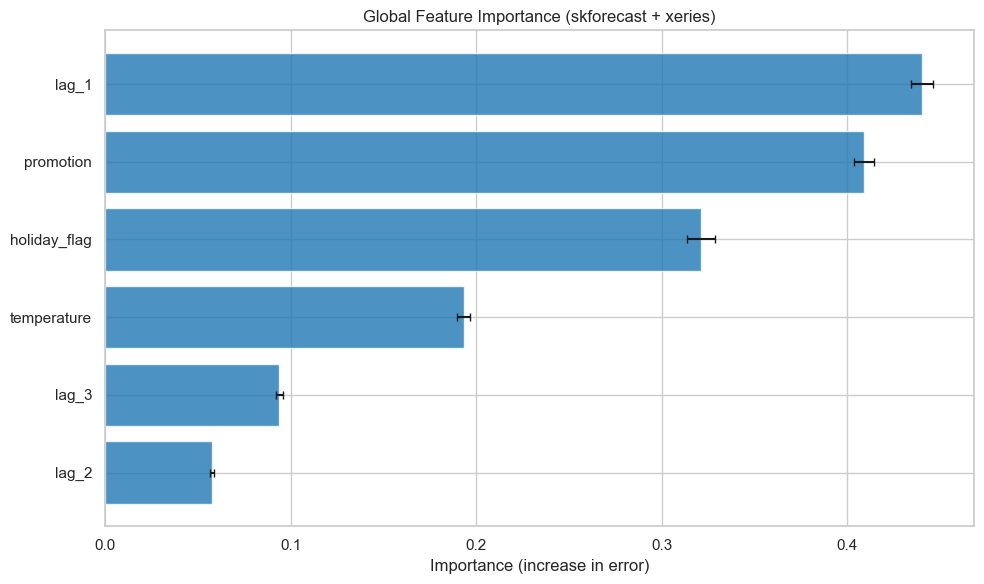

Saved importance tables to E:\research\beyond-global-averages\outputs\tables


In [10]:
# Visualize global importance
fig, ax = plot_importance_bar(
    global_result,
    max_features=12,
    title='Global Feature Importance (skforecast + xeries)',
)
fig.savefig(FIGURE_DIR / '01_global_importance.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_global_importance.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved global importance figures to {FIGURE_DIR}')
plt.show()

# Export CSV tables
importance_df.to_csv(TABLE_DIR / '01_global_importance.csv', index=False)

# Export LaTeX table
latex_importance = importance_df.to_latex(index=False, float_format='%.4f',
    caption='Global feature importance scores.',
    label='tab:01_global_importance')
with open(TABLE_DIR / '01_global_importance.tex', 'w') as f:
    f.write(latex_importance)
print(f'Saved importance tables to {TABLE_DIR}')

Computing sklearn permutation importance...
=== xeries vs sklearn permutation importance (top 12 by xeries) ===


,feature,importance,std,sklearn_importance,sklearn_std,importance_diff
0,lag_1,0.439969,0.005921,0.665151,0.008479,-0.225182
1,promotion,0.409044,0.005460,0.410938,0.004363,-0.001895
2,holiday_flag,0.321022,0.007393,0.325219,0.006275,-0.004197
3,temperature,0.193135,0.003649,0.318577,0.005256,-0.125443
4,lag_3,0.093838,0.001975,0.122568,0.001945,-0.028730
5,lag_2,0.057393,0.001043,0.074365,0.001017,-0.016972


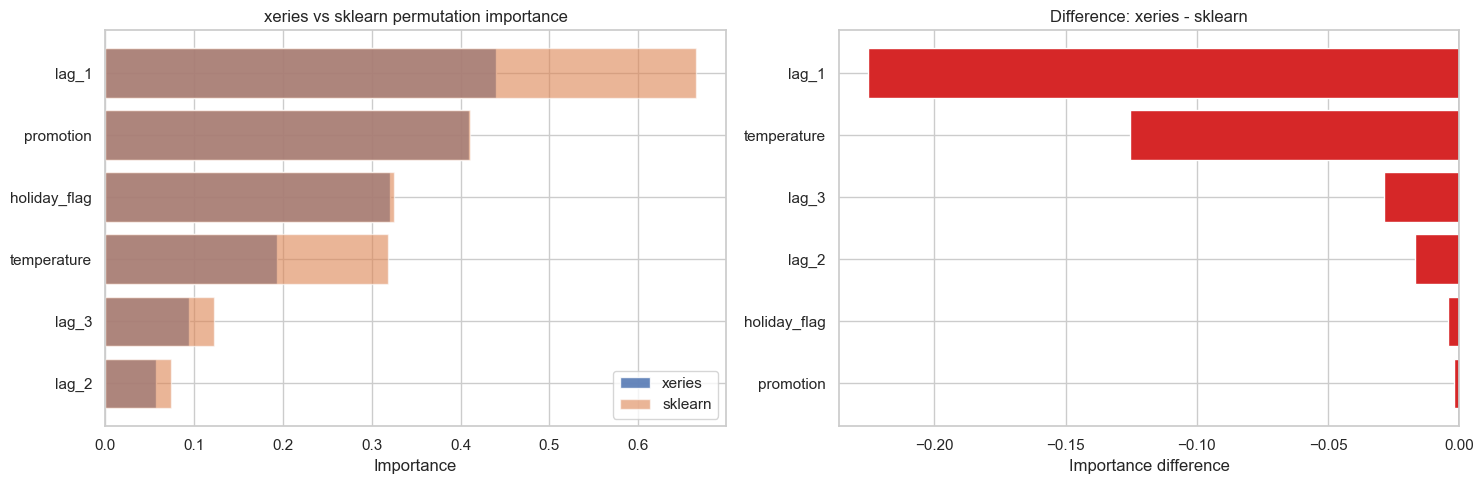

Spearman rank correlation: 1.000


In [30]:
print('Computing sklearn permutation importance...')

sk_model = getattr(forecaster, 'regressor_', forecaster.regressor)
sklearn_pi = permutation_importance(
    sk_model,
    X_train_sk,
    y_train_sk,
    n_repeats=20,
    random_state=RANDOM_SEED,
    scoring='neg_mean_squared_error',
)

sklearn_importance_df = pd.DataFrame({
    'feature': X_train_sk.columns,
    'sklearn_importance': sklearn_pi.importances_mean,
    'sklearn_std': sklearn_pi.importances_std,
}).sort_values('sklearn_importance', ascending=False)

comparison_df = (
    importance_df.merge(sklearn_importance_df, on='feature', how='inner')
    .assign(importance_diff=lambda df: df['importance'] - df['sklearn_importance'])
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
 )

print('=== xeries vs sklearn permutation importance (top 12 by xeries) ===')
display(comparison_df.head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

top_compare = comparison_df.head(12).iloc[::-1]
axes[0].barh(top_compare['feature'], top_compare['importance'], label='xeries', alpha=0.85)
axes[0].barh(top_compare['feature'], top_compare['sklearn_importance'], label='sklearn', alpha=0.6)
axes[0].set_title('xeries vs sklearn permutation importance')
axes[0].set_xlabel('Importance')
axes[0].legend()

top_diff = comparison_df.reindex(
    comparison_df['importance_diff'].abs().sort_values(ascending=False).head(12).index
 ).iloc[::-1]
axes[1].barh(top_diff['feature'], top_diff['importance_diff'], color='#d62728')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Difference: xeries - sklearn')
axes[1].set_xlabel('Importance difference')

plt.tight_layout()
plt.show()

rank_corr = comparison_df['importance'].rank().corr(
    comparison_df['sklearn_importance'].rank(),
    method='spearman',
)
print(f'Spearman rank correlation: {rank_corr:.3f}')

### Observation

The global importance shows moderate values for both `temperature` and `holiday_flag`. But this is misleading!
- `temperature` only affects urban stores
- `holiday_flag` only affects rural stores

The global view averages out these effects, hiding the true story.

## 7. Compute Per-Series Feature Importance

Now let's use `explain_per_series()` to reveal the **true heterogeneous effects**.

In [ ]:
# Compute per-series importance using the detected series column
per_series_results_raw = explainer.explain_per_series(
    X=X_train_sk,
    y=y_train_sk,
    series_col=series_col,
    features=explain_features,
)

# Map ordinal codes to readable series names
alphabetical_series_ids = sorted(series_ids)
per_series_results = {}

for key, value in per_series_results_raw.items():
    readable_key = None
    
    # Already a string label
    if key in series_ids:
        readable_key = key
    else:
        # Try integer-like code mapped to alphabetical order
        try:
            key_int = int(key)
            if 0 <= key_int < len(alphabetical_series_ids):
                readable_key = alphabetical_series_ids[key_int]
        except (TypeError, ValueError):
            readable_key = None
    
    if readable_key is None:
        readable_key = str(key)
    
    per_series_results[readable_key] = value

print(f"Computed importance for {len(per_series_results)} series")
print(f"Series: {list(per_series_results.keys())}")

# Display results for each series
for series_id, result in per_series_results.items():
    # Determine group for this series
    group = next((g for g in GROUPS if g in series_id), 'unknown')
    print(f"\n=== {series_id} ({group}) ===")
    df = result.to_dataframe()
    # Highlight exogenous features
    for _, row in df.iterrows():
        marker = " <-- EXOG" if row['feature'] in EXOG_FEATURE_NAMES else ""
        print(f"  {row['feature']:15} {row['importance']:8.4f}{marker}")

e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

Computed importance for 6 series
Mapped series keys: ['urban_001', 'urban_002', 'urban_003', 'rural_001', 'rural_002', 'rural_003']


e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
e:\research\beyond-global-averages\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fit

In [12]:
# Display results for each series
for series_id, result in per_series_results.items():
    region = 'URBAN' if 'urban' in series_id else 'RURAL'
    print(f"\n=== {series_id} ({region}) ===")
    df = result.to_dataframe()
    # Highlight exogenous features
    for _, row in df.iterrows():
        marker = " <-- EXOG" if row['feature'] in exog_features else ""
        print(f"  {row['feature']:15} {row['importance']:8.4f}{marker}")


=== urban_001 (URBAN) ===
  lag_1             0.7790
  promotion         0.4142 <-- EXOG
  temperature       0.3860 <-- EXOG
  lag_3             0.1166
  lag_2             0.0707
  holiday_flag      0.0056 <-- EXOG

=== urban_002 (URBAN) ===
  lag_1             0.7884
  promotion         0.4138 <-- EXOG
  temperature       0.4092 <-- EXOG
  lag_3             0.1269
  lag_2             0.0729
  holiday_flag      0.0023 <-- EXOG

=== urban_003 (URBAN) ===
  lag_1             0.7830
  promotion         0.4191 <-- EXOG
  temperature       0.4135 <-- EXOG
  lag_3             0.1321
  lag_2             0.0711
  holiday_flag      0.0033 <-- EXOG

=== rural_001 (RURAL) ===
  holiday_flag      0.6489 <-- EXOG
  lag_1             0.5596
  promotion         0.4153 <-- EXOG
  lag_3             0.1198
  lag_2             0.0752
  temperature       0.0306 <-- EXOG

=== rural_002 (RURAL) ===
  holiday_flag      0.6436 <-- EXOG
  lag_1             0.5259
  promotion         0.3974 <-- EXOG
  lag_3   

## 8. Visualize Per-Series Importance

Saved per-series importance figures to E:\research\beyond-global-averages\outputs\figures


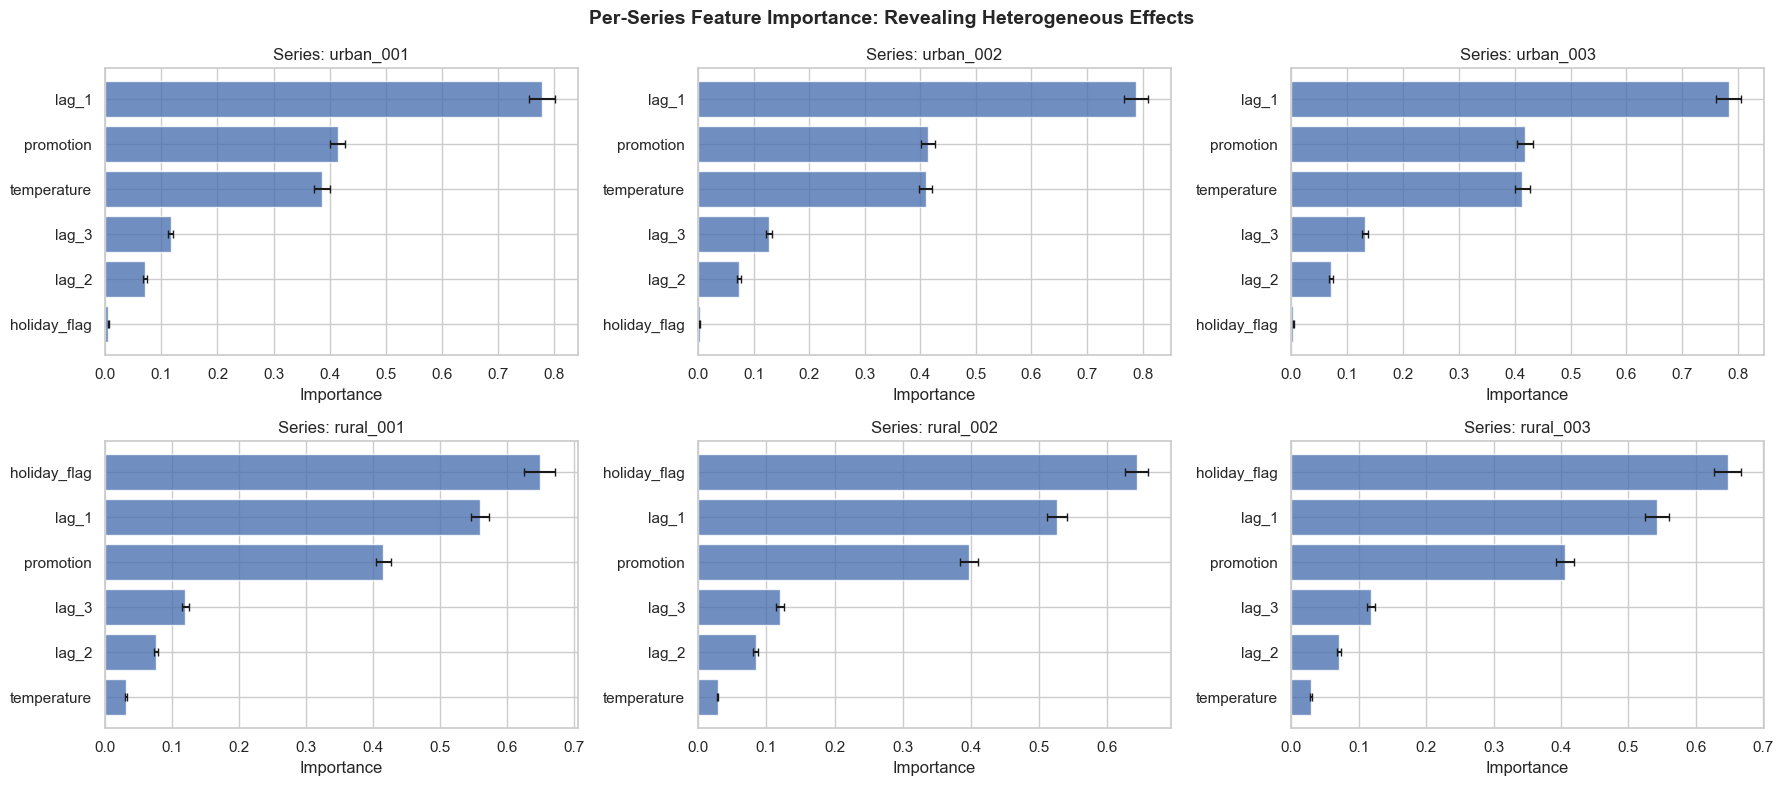

Saved per-series importance tables to E:\research\beyond-global-averages\outputs\tables


In [13]:
# Grid of bar charts for all series
fig, axes = plot_importance_per_series(
    per_series_results,
    max_features=6,
    ncols=3,
    title="Per-Series Feature Importance: Revealing Heterogeneous Effects"
)
fig.savefig(FIGURE_DIR / '01_per_series_importance.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_per_series_importance.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved per-series importance figures to {FIGURE_DIR}')
plt.show()

# Export per-series importance table
per_series_df = pd.concat([
    r.to_dataframe().assign(series=name)
    for name, r in per_series_results.items()
])
per_series_df.to_csv(TABLE_DIR / '01_per_series_importance.csv', index=False)

# Export LaTeX table
latex_per_series = per_series_df.to_latex(index=False, float_format='%.4f',
    caption='Per-series feature importance scores.',
    label='tab:01_per_series_importance')
with open(TABLE_DIR / '01_per_series_importance.tex', 'w') as f:
    f.write(latex_per_series)
print(f'Saved per-series importance tables to {TABLE_DIR}')

In [14]:
import importlib
import xeries

# import plot_importance_heatmap
# Force reload xeries in Jupyter (useful after local code changes)

importlib.reload(xeries)

from xeries import (
    ConditionalPermutationImportance,
    SkforecastAdapter,
    plot_importance_bar,
    plot_importance_heatmap,
)


Saved heatmap to E:\research\beyond-global-averages\outputs\figures


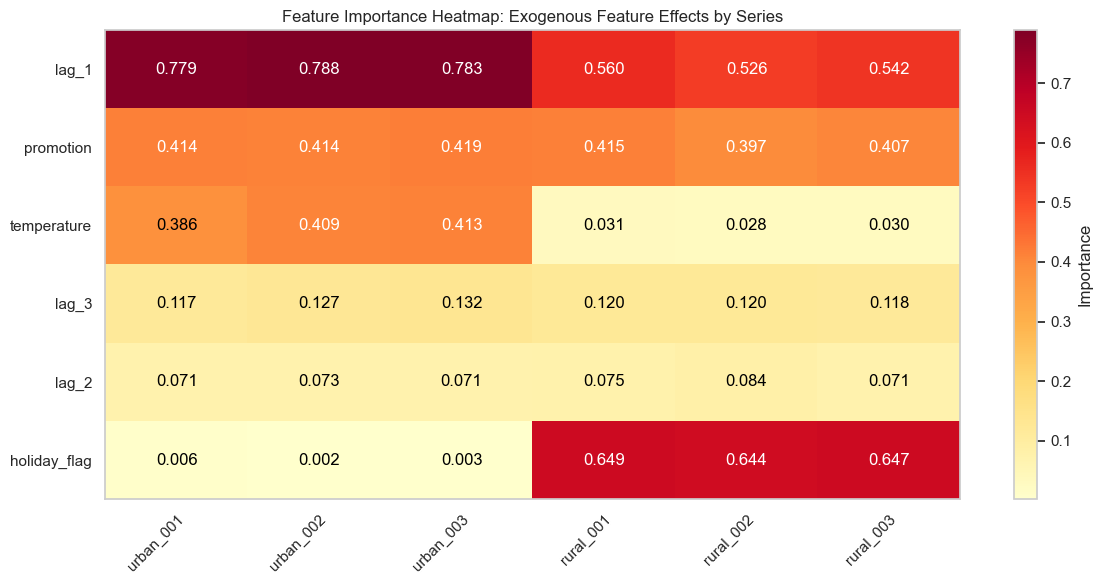

In [15]:
# Heatmap comparison across all series
fig, ax = plot_importance_heatmap(
    per_series_results,
    features=explain_features,
    figsize=(12, 6),
    title="Feature Importance Heatmap: Exogenous Feature Effects by Series"
)
fig.savefig(FIGURE_DIR / '01_importance_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_importance_heatmap.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved heatmap to {FIGURE_DIR}')
plt.show()

## 9. Compare Urban vs Rural Groups

Let's aggregate by region to clearly see the pattern.

In [ ]:
# Separate results by group
group_results = {group: {} for group in GROUPS}

for series_id, result in per_series_results.items():
    # Determine which group this series belongs to
    for group in GROUPS:
        if group in series_id:
            group_results[group][series_id] = result
            break

# Aggregate importance by group
def aggregate_importance(results_dict):
    all_importances = {}
    for _, result in results_dict.items():
        for feat, imp in zip(result.feature_names, result.importances):
            all_importances.setdefault(feat, []).append(float(imp))
    return {feat: float(np.mean(vals)) for feat, vals in all_importances.items()}

group_averages = {}
for group in GROUPS:
    group_avg_all = aggregate_importance(group_results[group])
    group_averages[group] = {f: group_avg_all.get(f, 0.0) for f in EXOG_FEATURE_NAMES}

# Global average for exogenous features only
global_avg = {
    f: float(global_result.importances[global_result.feature_names.index(f)])
    for f in EXOG_FEATURE_NAMES
    if f in global_result.feature_names
}

# Build comparison dataframe
comparison_data = {'Feature': EXOG_FEATURE_NAMES}
for group in GROUPS:
    comparison_data[f'{group} (avg)'] = [group_averages[group].get(f, 0.0) for f in EXOG_FEATURE_NAMES]
comparison_data['Global'] = [global_avg.get(f, 0.0) for f in EXOG_FEATURE_NAMES]

comparison_df = pd.DataFrame(comparison_data).set_index('Feature')

print('=== Exogenous Feature Importance Comparison ===')
print(comparison_df.round(4).to_string())

=== Exogenous Feature Importance Comparison ===
              Urban (avg)  Rural (avg)  Global
Feature                                       
temperature        0.4029       0.0295  0.1931
holiday_flag       0.0037       0.6466  0.3210
promotion          0.4157       0.4064  0.4090


Saved Urban vs Rural comparison to E:\research\beyond-global-averages\outputs\figures


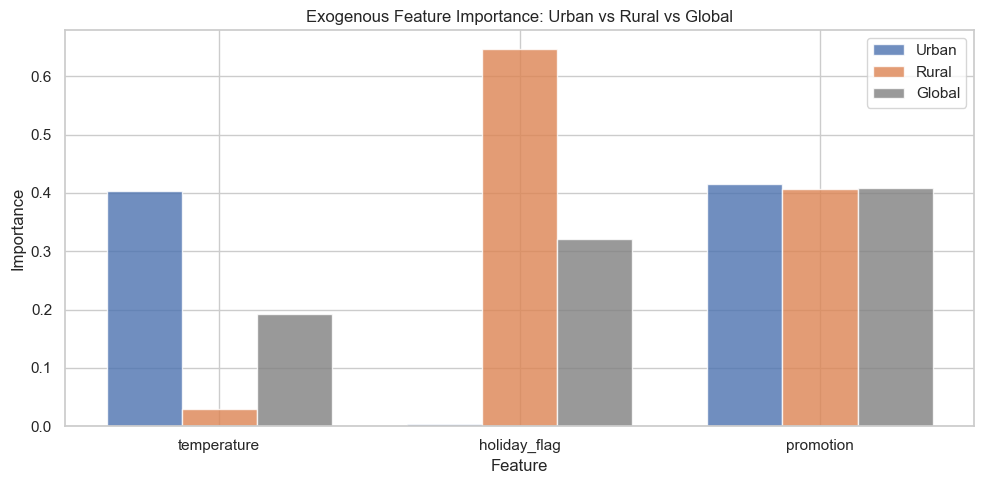

In [17]:
# Visualize exogenous feature comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

x = np.arange(len(exog_features))
width = 0.25

ax.bar(x - width, comparison_df['Urban (avg)'], width, label='Urban', alpha=0.8)
ax.bar(x, comparison_df['Rural (avg)'], width, label='Rural', alpha=0.8)
ax.bar(x + width, comparison_df['Global'], width, label='Global', alpha=0.8, color='gray')

ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.set_title('Exogenous Feature Importance: Urban vs Rural vs Global')
ax.set_xticks(x)
ax.set_xticklabels(exog_features)
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_urban_vs_rural_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_urban_vs_rural_comparison.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved Urban vs Rural comparison to {FIGURE_DIR}')
plt.show()

## 10. Key Insights

### What Per-Series Analysis Reveals:

| Feature | True Effect | Global Importance | Per-Series Finding |
|---------|-------------|-------------------|--------------------|
| `temperature` | Urban only | Moderate | High for urban, ~0 for rural |
| `holiday_flag` | Rural only | Moderate | High for rural, ~0 for urban |
| `promotion` | All series | Moderate | Consistent across all series |

### Why This Matters:

1. **Better Feature Understanding**: Global importance would suggest both `temperature` and `holiday_flag` are moderately important everywhere. Per-series analysis reveals the true, actionable insight.

2. **Targeted Interventions**: If you're planning a marketing campaign:
   - For urban stores: Focus on temperature-based promotions (e.g., hot weather discounts)
   - For rural stores: Plan around holidays and tourism seasons

3. **Model Debugging**: If predictions are poor for specific series, per-series importance helps identify which features the model is (incorrectly) relying on.

4. **Feature Engineering**: Knowing that `temperature` only matters for urban stores, you might create interaction features like `temperature * is_urban`.

In [ ]:
# Final summary table
print("\n" + "="*60)
print("SUMMARY: Heterogeneous Exogenous Feature Effects")
print("="*60)

def dominant_group(feature_name: str) -> str:
    vals = {group: group_averages[group].get(feature_name, 0.0) for group in GROUPS}
    if max(vals.values()) < 1e-9:
        return "none"
    return max(vals, key=vals.get)

for feat in EXOG_FEATURE_NAMES:
    print(f"\n{feat}:")
    doc = EXOG_FEATURE_DOCS.get(feat, "")
    if doc:
        print(f"  Documentation: {doc}")
    for group in GROUPS:
        imp = group_averages[group].get(feat, 0.0)
        print(f"  {group:8} importance: {imp:.4f}")
    print(f"  Global importance: {global_avg.get(feat, 0.0):.4f}")
    print(f"  Dominant group: {dominant_group(feat).upper()}")

print("\n" + "="*60)


SUMMARY: Heterogeneous Exogenous Feature Effects

Temperature Effect:
  Urban stores:  0.4029
  Rural stores:  0.0295
  Dominant group: URBAN

Holiday Flag Effect:
  Urban stores:  0.0037
  Rural stores:  0.6466
  Dominant group: RURAL

Promotion Effect:
  Urban stores:  0.4157
  Rural stores:  0.4064
  Dominant group: URBAN



## 11. Out-of-Distribution Analysis

This section validates the methodological choice of **conditional permutation** over global permutation.
We demonstrate that:
- **Global permutation** creates unrealistic, out-of-distribution data by destroying series-specific patterns
- **Conditional permutation** preserves the original data distribution within each series

We measure distribution distances using Wasserstein distance and Kolmogorov-Smirnov statistics.

In [ ]:
from scipy.stats import wasserstein_distance, ks_2samp

# Exogenous features for OOD analysis
ood_exog_features = EXOG_FEATURE_NAMES
print(f'Exogenous features for OOD analysis: {ood_exog_features}')

# Create permuted datasets
np.random.seed(RANDOM_SEED)

X_global_perm = X_train_sk.copy()
X_cond_perm = X_train_sk.copy()

for feat in ood_exog_features:
    # Global permutation: shuffle across ALL rows (ignores series boundaries)
    X_global_perm[feat] = np.random.permutation(X_train_sk[feat].values)
    
    # Conditional permutation: shuffle WITHIN each series group
    for series_id_code in X_train_sk[series_col].unique():
        mask = X_train_sk[series_col] == series_id_code
        X_cond_perm.loc[mask, feat] = np.random.permutation(
            X_train_sk.loc[mask, feat].values
        )

print(f'Created permuted datasets with shape: {X_global_perm.shape}')

Exogenous features for OOD analysis: ['temperature', 'holiday_flag', 'promotion']
Created permuted datasets with shape: (10932, 7)


In [ ]:
# Compute distribution distances per series and feature
distance_records = []

for series_id_code in X_train_sk[series_col].unique():
    mask = X_train_sk[series_col] == series_id_code
    
    # Map back to readable series ID
    if isinstance(series_id_code, int) and 0 <= series_id_code < len(alphabetical_series_ids):
        readable_id = alphabetical_series_ids[series_id_code]
    else:
        readable_id = str(series_id_code)
    
    for feat in ood_exog_features:
        orig_vals = X_train_sk.loc[mask, feat].values
        global_vals = X_global_perm.loc[mask, feat].values
        cond_vals = X_cond_perm.loc[mask, feat].values
        
        # Wasserstein distance (Earth Mover's Distance)
        wd_global = wasserstein_distance(orig_vals, global_vals)
        wd_cond = wasserstein_distance(orig_vals, cond_vals)
        
        # KS statistic
        ks_global, _ = ks_2samp(orig_vals, global_vals)
        ks_cond, _ = ks_2samp(orig_vals, cond_vals)
        
        distance_records.append({
            'series': readable_id,
            'feature': feat,
            'wasserstein_global': wd_global,
            'wasserstein_conditional': wd_cond,
            'ks_global': ks_global,
            'ks_conditional': ks_cond,
        })

ood_df = pd.DataFrame(distance_records)
print('Distribution distance metrics computed.')
display(ood_df.head(12))

Distribution distance metrics computed.


e:\research\beyond-global-averages\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,series,feature,wasserstein_global,wasserstein_conditional,ks_global,ks_conditional
0,3,temperature,6.191182,0.0,0.232711,0.0
1,3,holiday_flag,0.014270,0.0,0.014270,0.0
2,3,promotion,0.010977,0.0,0.010977,0.0
3,4,temperature,7.769518,0.0,0.272777,0.0
4,4,holiday_flag,0.000549,0.0,0.000549,0.0
5,4,promotion,0.017014,0.0,0.017014,0.0
6,5,temperature,9.150738,0.0,0.315038,0.0
7,5,holiday_flag,0.009330,0.0,0.009330,0.0
8,5,promotion,0.008782,0.0,0.008782,0.0
9,0,temperature,9.625531,0.0,0.326015,0.0


In [21]:
# Aggregate distances by feature
ood_summary = ood_df.groupby('feature').agg({
    'wasserstein_global': 'mean',
    'wasserstein_conditional': 'mean',
    'ks_global': 'mean',
    'ks_conditional': 'mean',
}).reset_index()

# Calculate ratio (how much worse is global vs conditional)
ood_summary['wd_ratio'] = ood_summary['wasserstein_global'] / (ood_summary['wasserstein_conditional'] + 1e-10)
ood_summary['ks_ratio'] = ood_summary['ks_global'] / (ood_summary['ks_conditional'] + 1e-10)

print('=== OOD Distance Summary (averaged across series) ===')
display(ood_summary)

=== OOD Distance Summary (averaged across series) ===


,feature,wasserstein_global,wasserstein_conditional,ks_global,ks_conditional,wd_ratio,ks_ratio
0,holiday_flag,0.006586,0.0,0.006586,0.0,6.586169e+07,6.586169e+07
1,promotion,0.011709,0.0,0.011709,0.0,1.170874e+08,1.170874e+08
2,temperature,7.695999,0.0,0.268569,0.0,7.695999e+10,2.685693e+09


Saved OOD distance comparison to E:\research\beyond-global-averages\outputs\figures


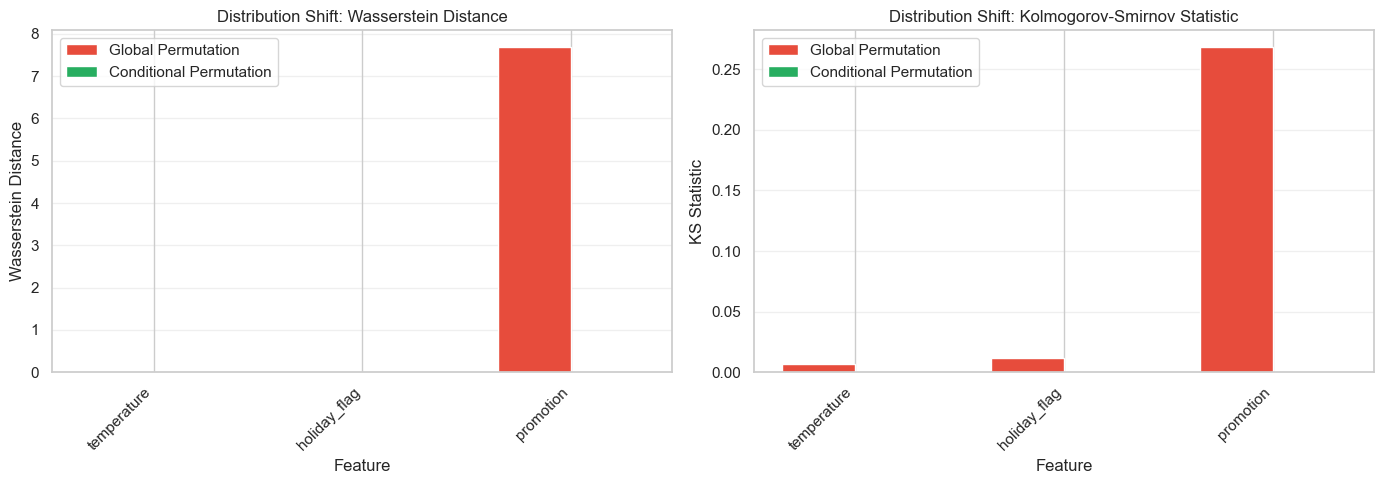

In [22]:
# Bar chart: Wasserstein distance comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(exog_features))
width = 0.35

# Wasserstein Distance
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, ood_summary['wasserstein_global'], width, label='Global Permutation', color='#e74c3c')
bars2 = ax1.bar(x + width/2, ood_summary['wasserstein_conditional'], width, label='Conditional Permutation', color='#27ae60')
ax1.set_xlabel('Feature')
ax1.set_ylabel('Wasserstein Distance')
ax1.set_title('Distribution Shift: Wasserstein Distance')
ax1.set_xticks(x)
ax1.set_xticklabels(exog_features, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# KS Statistic
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, ood_summary['ks_global'], width, label='Global Permutation', color='#e74c3c')
bars4 = ax2.bar(x + width/2, ood_summary['ks_conditional'], width, label='Conditional Permutation', color='#27ae60')
ax2.set_xlabel('Feature')
ax2.set_ylabel('KS Statistic')
ax2.set_title('Distribution Shift: Kolmogorov-Smirnov Statistic')
ax2.set_xticks(x)
ax2.set_xticklabels(exog_features, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_distance_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_distance_comparison.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved OOD distance comparison to {FIGURE_DIR}')
plt.show()

Saved per-series distribution overlay to E:\research\beyond-global-averages\outputs\figures


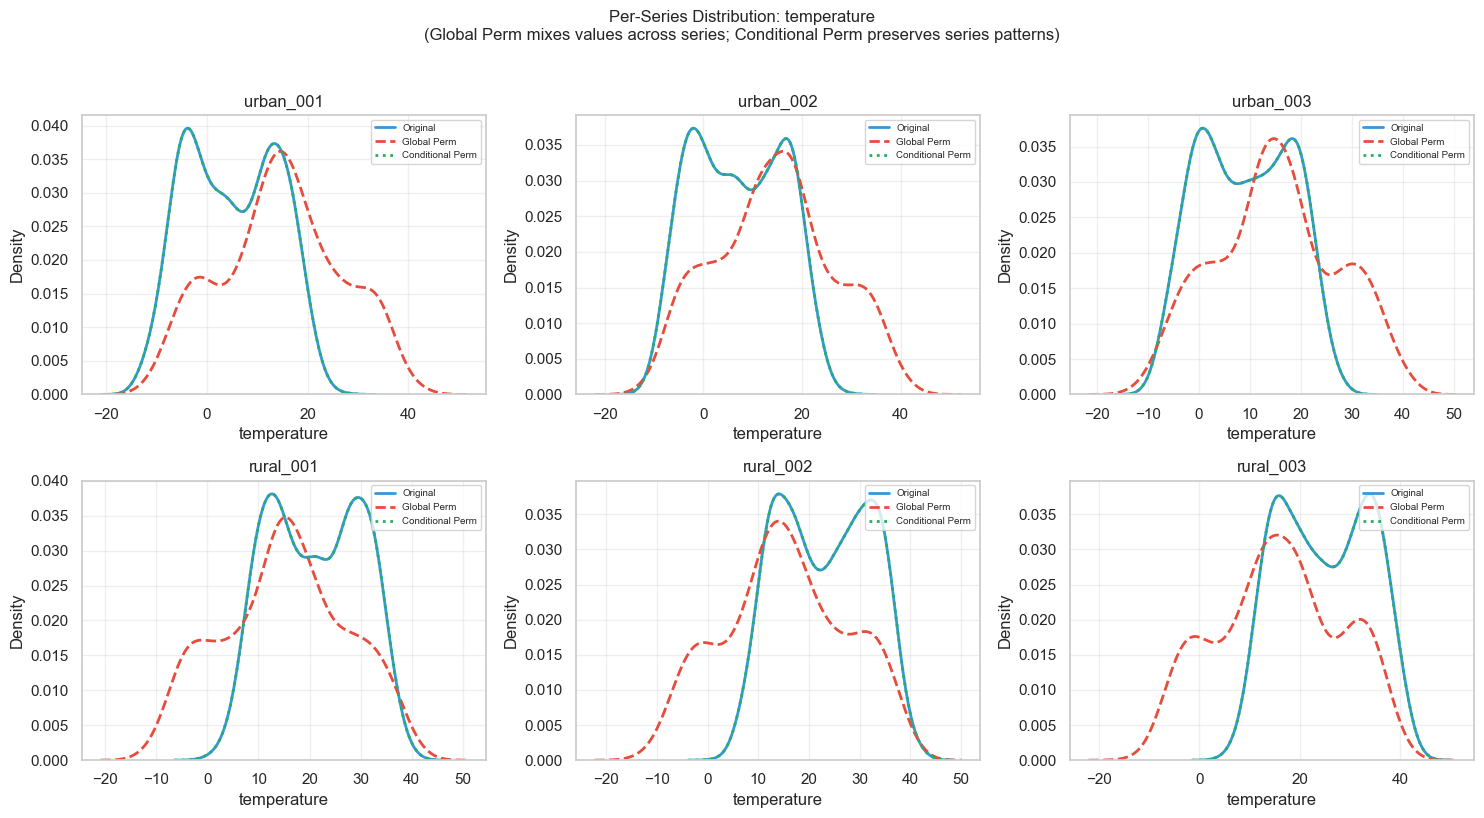

In [ ]:
# Per-series KDE distribution for an exogenous feature
# This shows how global permutation destroys series-specific patterns
# Use first exogenous feature as example
feat_example = EXOG_FEATURE_NAMES[0]
unique_series = sorted(X_train_sk[series_col].unique())
n_series = len(unique_series)
ncols = min(3, n_series)
nrows = (n_series + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten() if n_series > 1 else [axes]

for idx, series_id_code in enumerate(unique_series):
    mask = X_train_sk[series_col] == series_id_code
    
    # Map back to readable series ID
    if isinstance(series_id_code, int) and 0 <= series_id_code < len(alphabetical_series_ids):
        series_name = alphabetical_series_ids[series_id_code]
    else:
        series_name = str(series_id_code)
    
    ax = axes[idx]
    
    # Plot KDE for this series: original vs permuted
    orig_data = X_train_sk.loc[mask, feat_example].values
    global_data = X_global_perm.loc[mask, feat_example].values
    cond_data = X_cond_perm.loc[mask, feat_example].values
    
    sns.kdeplot(orig_data, ax=ax, label='Original', color='#3498db', linewidth=2)
    sns.kdeplot(global_data, ax=ax, label='Global Perm', color='#e74c3c', linewidth=2, linestyle='--')
    sns.kdeplot(cond_data, ax=ax, label='Conditional Perm', color='#27ae60', linewidth=2, linestyle=':')
    
    ax.set_title(f'{series_name}')
    ax.set_xlabel(f'{feat_example}')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)

# Hide unused subplots
for idx in range(n_series, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Per-Series Distribution: {feat_example}\n(Global Perm mixes values across series; Conditional Perm preserves series patterns)', 
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_distribution_overlay.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_distribution_overlay.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved per-series distribution overlay to {FIGURE_DIR}')
plt.show()

In [ ]:
# Compute per-series MEAN SHIFT - this shows how permutation changes series-specific statistics
mean_shift_records = []

for series_id_code in X_train_sk[series_col].unique():
    mask = X_train_sk[series_col] == series_id_code
    
    # Map back to readable series ID
    if isinstance(series_id_code, int) and 0 <= series_id_code < len(alphabetical_series_ids):
        series_name = alphabetical_series_ids[series_id_code]
    else:
        series_name = str(series_id_code)
    
    for feat in ood_exog_features:
        orig_mean = X_train_sk.loc[mask, feat].mean()
        orig_std = X_train_sk.loc[mask, feat].std()
        
        global_mean = X_global_perm.loc[mask, feat].mean()
        global_std = X_global_perm.loc[mask, feat].std()
        
        cond_mean = X_cond_perm.loc[mask, feat].mean()
        cond_std = X_cond_perm.loc[mask, feat].std()
        
        mean_shift_records.append({
            'series': series_name,
            'feature': feat,
            'original_mean': orig_mean,
            'global_mean_shift': abs(global_mean - orig_mean),
            'cond_mean_shift': abs(cond_mean - orig_mean),
            'global_std_shift': abs(global_std - orig_std),
            'cond_std_shift': abs(cond_std - orig_std),
        })

mean_shift_df = pd.DataFrame(mean_shift_records)
print('Per-series mean/std shift analysis:')
display(mean_shift_df)

Per-series mean/std shift analysis:


,series,feature,original_mean,global_mean_shift,cond_mean_shift,global_std_shift,cond_std_shift
0,3,temperature,21.127957,6.062447,0.000000e+00,3.270277,0.0
1,3,holiday_flag,0.137212,0.014270,0.000000e+00,0.014451,0.0
2,3,promotion,0.290889,0.010977,0.000000e+00,0.004896,0.0
3,4,temperature,23.086930,7.769518,0.000000e+00,3.285137,0.0
4,4,holiday_flag,0.146542,0.000549,0.000000e+00,0.000550,0.0
5,4,promotion,0.315038,0.017014,0.000000e+00,0.007143,0.0
6,5,temperature,24.982045,9.150738,0.000000e+00,3.351541,0.0
7,5,holiday_flag,0.156422,0.009330,0.000000e+00,0.009060,0.0
8,5,promotion,0.309550,0.008782,0.000000e+00,0.003717,0.0
9,0,temperature,4.992887,9.625531,0.000000e+00,3.008802,0.0


Saved mean shift heatmap to E:\research\beyond-global-averages\outputs\figures


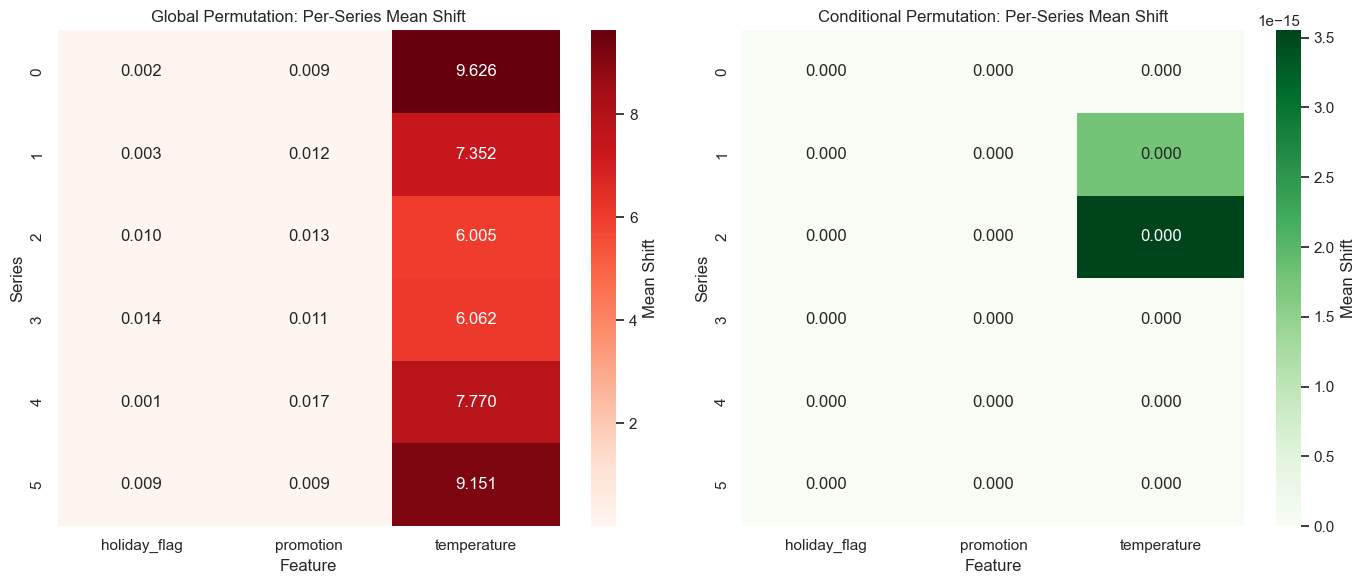

In [25]:
# Per-series heatmap of MEAN SHIFT - this is more informative than Wasserstein for showing
# how global permutation destroys series-specific patterns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Global permutation mean shift
pivot_global = mean_shift_df.pivot(index='series', columns='feature', values='global_mean_shift')
sns.heatmap(pivot_global, annot=True, fmt='.3f', cmap='Reds', ax=axes[0], cbar_kws={'label': 'Mean Shift'})
axes[0].set_title('Global Permutation: Per-Series Mean Shift')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Series')

# Conditional permutation mean shift (should be ~0)
pivot_cond = mean_shift_df.pivot(index='series', columns='feature', values='cond_mean_shift')
sns.heatmap(pivot_cond, annot=True, fmt='.3f', cmap='Greens', ax=axes[1], cbar_kws={'label': 'Mean Shift'})
axes[1].set_title('Conditional Permutation: Per-Series Mean Shift')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Series')

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_mean_shift_heatmap.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_mean_shift_heatmap.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved mean shift heatmap to {FIGURE_DIR}')
plt.show()

Saved statistics shift chart to E:\research\beyond-global-averages\outputs\figures


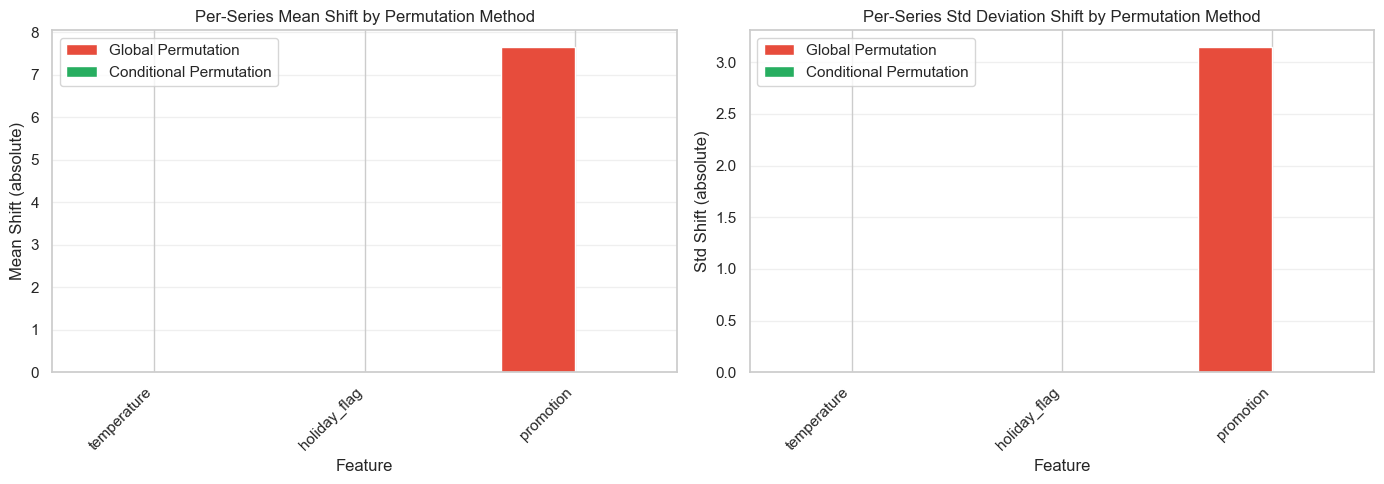


=== Mean Shift Summary ===
Global permutation average mean shift: 2.5597
Conditional permutation average mean shift: 0.000000

Key insight: Conditional permutation preserves per-series statistics (near-zero shift),
while global permutation significantly distorts series-specific patterns.


In [26]:
# Summary bar chart: Average mean shift across all series
mean_shift_summary = mean_shift_df.groupby('feature').agg({
    'global_mean_shift': 'mean',
    'cond_mean_shift': 'mean',
    'global_std_shift': 'mean',
    'cond_std_shift': 'mean',
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(exog_features))
width = 0.35

# Mean Shift
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, mean_shift_summary['global_mean_shift'], width, 
                label='Global Permutation', color='#e74c3c')
bars2 = ax1.bar(x + width/2, mean_shift_summary['cond_mean_shift'], width, 
                label='Conditional Permutation', color='#27ae60')
ax1.set_xlabel('Feature')
ax1.set_ylabel('Mean Shift (absolute)')
ax1.set_title('Per-Series Mean Shift by Permutation Method')
ax1.set_xticks(x)
ax1.set_xticklabels(exog_features, rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Std Shift
ax2 = axes[1]
bars3 = ax2.bar(x - width/2, mean_shift_summary['global_std_shift'], width, 
                label='Global Permutation', color='#e74c3c')
bars4 = ax2.bar(x + width/2, mean_shift_summary['cond_std_shift'], width, 
                label='Conditional Permutation', color='#27ae60')
ax2.set_xlabel('Feature')
ax2.set_ylabel('Std Shift (absolute)')
ax2.set_title('Per-Series Std Deviation Shift by Permutation Method')
ax2.set_xticks(x)
ax2.set_xticklabels(exog_features, rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURE_DIR / '01_ood_statistics_shift.pdf', format='pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURE_DIR / '01_ood_statistics_shift.png', format='png', dpi=300, bbox_inches='tight')
print(f'Saved statistics shift chart to {FIGURE_DIR}')
plt.show()

print('\n=== Mean Shift Summary ===')
print(f'Global permutation average mean shift: {mean_shift_summary["global_mean_shift"].mean():.4f}')
print(f'Conditional permutation average mean shift: {mean_shift_summary["cond_mean_shift"].mean():.6f}')
print(f'\nKey insight: Conditional permutation preserves per-series statistics (near-zero shift),')
print(f'while global permutation significantly distorts series-specific patterns.')

In [27]:
# Export all OOD analysis metrics
ood_df.to_csv(TABLE_DIR / '01_ood_distances.csv', index=False)
ood_summary.to_csv(TABLE_DIR / '01_ood_distances_summary.csv', index=False)
mean_shift_df.to_csv(TABLE_DIR / '01_ood_mean_shift.csv', index=False)
mean_shift_summary.to_csv(TABLE_DIR / '01_ood_mean_shift_summary.csv', index=False)

# LaTeX exports
latex_ood = ood_summary.to_latex(index=False, float_format='%.4f',
    caption='Out-of-distribution analysis: Wasserstein and KS distances.',
    label='tab:01_ood_distances')
with open(TABLE_DIR / '01_ood_distances.tex', 'w') as f:
    f.write(latex_ood)

latex_mean_shift = mean_shift_summary.to_latex(index=False, float_format='%.4f',
    caption='Per-series statistics shift: global vs conditional permutation.',
    label='tab:01_ood_mean_shift')
with open(TABLE_DIR / '01_ood_mean_shift.tex', 'w') as f:
    f.write(latex_mean_shift)

print(f'Saved OOD tables to {TABLE_DIR}')
print('\n' + '='*60)
print('OOD ANALYSIS SUMMARY')
print('='*60)
print(f'\nWasserstein Distance (averaged across features):')
print(f'  Global permutation:      {ood_summary["wasserstein_global"].mean():.4f}')
print(f'  Conditional permutation: {ood_summary["wasserstein_conditional"].mean():.6f}')
print(f'\nPer-Series Mean Shift (averaged across features):')
print(f'  Global permutation:      {mean_shift_summary["global_mean_shift"].mean():.4f}')
print(f'  Conditional permutation: {mean_shift_summary["cond_mean_shift"].mean():.6f}')
print(f'\nConclusion:')
print(f'  - Global permutation destroys series-specific patterns (high mean shift)')
print(f'  - Conditional permutation preserves per-series statistics (near-zero shift)')
print(f'  - This validates using conditional permutation for multi-series importance')
print('='*60)

Saved OOD tables to E:\research\beyond-global-averages\outputs\tables

OOD ANALYSIS SUMMARY

Wasserstein Distance (averaged across features):
  Global permutation:      2.5714
  Conditional permutation: 0.000000

Per-Series Mean Shift (averaged across features):
  Global permutation:      2.5597
  Conditional permutation: 0.000000

Conclusion:
  - Global permutation destroys series-specific patterns (high mean shift)
  - Conditional permutation preserves per-series statistics (near-zero shift)
  - This validates using conditional permutation for multi-series importance
